# SRIP 2026 — Earth Observation Pipeline
### Delhi-NCR Land Use Classification


In [1]:
# installing everything i need first
# rasterio is for reading the .tif land cover file
# geopandas handles the shapefiles/geojson stuff
!pip install geopandas rasterio scipy scikit-learn torch torchvision -q

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import geopandas as gpd
from shapely.geometry import Point, box

# rasterio is basically for reading geotiff files
# rowcol converts lat/lon into actual pixel positions in the tif
import rasterio
from rasterio.transform import rowcol
import rasterio.windows

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models  # models has resnet18 prebuilt
from PIL import Image

# defining paths so i dont have to type the full path every time
BASE = '/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed'
RGB_DIR = os.path.join(BASE, 'rgb')
NCR_PATH = os.path.join(BASE, 'delhi_ncr_region.geojson')
AIRSHED_PATH = os.path.join(BASE, 'delhi_airshed.geojson')
LANDCOVER_PATH = os.path.join(BASE, 'worldcover_bbox_delhi_ncr_2021.tif')

print('imports done')
print('total images in rgb folder:', len(os.listdir(RGB_DIR)))

imports done
total images in rgb folder: 9216


In [3]:
# just checking what the filenames look like before i do anything
sample = os.listdir(RGB_DIR)[:5]
print(sample)
# ok so the format is lat_lon.png
# like 28.2266_77.5234.png means lat=28.2266, lon=77.5234
# no separate csv needed, coordinates are in the filename itself

['28.2266_77.5234.png', '28.4266_77.2822.png', '28.7591_77.2058.png', '28.5355_77.3910.png', '28.2943_77.0234.png']


---
## Q1 - Spatial Reasoning and Data Filtering

In [4]:
# loading the boundary files
ncr = gpd.read_file(NCR_PATH)
airshed = gpd.read_file(AIRSHED_PATH)

print('ncr crs:', ncr.crs)         # should be 4326
print('airshed crs:', airshed.crs)
print('ncr shape:', ncr.shape)

ncr crs: EPSG:4326
airshed crs: EPSG:4326
ncr shape: (30, 1)


In [5]:
# for the grid i need to work in meters not degrees
# EPSG:32644 is UTM zone 44N which covers delhi area, units are in meters
# 4326 is degrees (lat/lon), cant make 60km grid in degrees directly

ncr_utm = ncr.to_crs('EPSG:32644')
airshed_utm = airshed.to_crs('EPSG:32644')

minx, miny, maxx, maxy = ncr_utm.total_bounds
print(f'bounds in meters: {minx:.0f}, {miny:.0f}, {maxx:.0f}, {maxy:.0f}')

# 60km = 60000 meters
GRID_SIZE = 60_000

# making grid cells by looping over the bounding box
grid_cells = []
x = minx
while x < maxx:
    y = miny
    while y < maxy:
        cell = box(x, y, x + GRID_SIZE, y + GRID_SIZE)
        grid_cells.append(cell)
        y += GRID_SIZE
    x += GRID_SIZE

grid_gdf = gpd.GeoDataFrame(geometry=grid_cells, crs='EPSG:32644')
print('number of grid cells:', len(grid_gdf))

# converting back to 4326 for plotting
grid_4326 = grid_gdf.to_crs('EPSG:4326')
ncr_4326 = ncr.to_crs('EPSG:4326')

bounds in meters: -39135, 2958988, 252194, 3324410
number of grid cells: 35


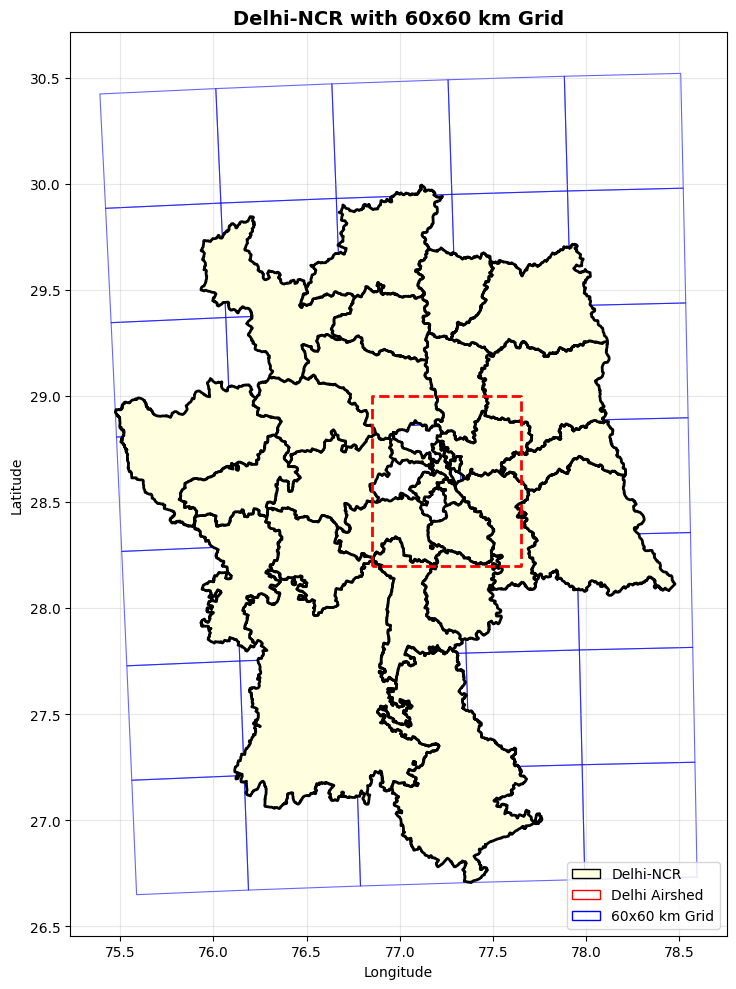

In [6]:
# plotting the map
fig, ax = plt.subplots(figsize=(10, 10))

ncr_4326.plot(ax=ax, facecolor='lightyellow', edgecolor='black', linewidth=2, zorder=2)
airshed.to_crs('EPSG:4326').plot(ax=ax, facecolor='none', edgecolor='red',
                                  linewidth=2, linestyle='--', zorder=3)
grid_4326.plot(ax=ax, facecolor='none', edgecolor='blue',
               linewidth=0.8, alpha=0.6, zorder=1)

ax.set_title('Delhi-NCR with 60x60 km Grid', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

legend_elements = [
    mpatches.Patch(facecolor='lightyellow', edgecolor='black', label='Delhi-NCR'),
    mpatches.Patch(facecolor='none', edgecolor='red', label='Delhi Airshed'),
    mpatches.Patch(facecolor='none', edgecolor='blue', label='60x60 km Grid')
]
ax.legend(handles=legend_elements, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('q1_grid_map.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# now filtering images that fall inside ncr boundary
# first parsing all filenames to get lat lon

all_images = [f for f in os.listdir(RGB_DIR) if f.endswith('.png')]
print('total images before filtering:', len(all_images))

records = []
for fname in all_images:
    try:
        # splitting '28.2266_77.5234.png' -> ['28.2266', '77.5234']
        parts = fname.replace('.png', '').split('_')
        lat = float(parts[0])
        lon = float(parts[1])
        records.append({'filename': fname, 'lat': lat, 'lon': lon})
    except:
        print('couldnt parse:', fname)

df = pd.DataFrame(records)
print('parsed rows:', len(df))
df.head()

total images before filtering: 9216
parsed rows: 9216


,filename,lat,lon
0,28.2266_77.5234.png,28.2266,77.5234
1,28.4266_77.2822.png,28.4266,77.2822
2,28.7591_77.2058.png,28.7591,77.2058
3,28.5355_77.3910.png,28.5355,77.3910
4,28.2943_77.0234.png,28.2943,77.0234


In [8]:
# creating point geometry for each image center
# Point takes (longitude, latitude) not (lat, lon) - tripped me up initially
geometry = [Point(row.lon, row.lat) for _, row in df.iterrows()]
images_gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')

# using shapely within() to check if point is inside the ncr polygon
ncr_union = ncr_4326.geometry.unary_union
images_gdf['inside_ncr'] = images_gdf.geometry.within(ncr_union)

filtered_gdf = images_gdf[images_gdf['inside_ncr']].reset_index(drop=True)

print('images before filtering:', len(df))
print('images after filtering:', len(filtered_gdf))
print('images removed:', len(df) - len(filtered_gdf))

/tmp/ipykernel_125/30112060.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  ncr_union = ncr_4326.geometry.unary_union


images before filtering: 9216
images after filtering: 8015
images removed: 1201


---
## Q2 - Label Construction and Dataset Preparation

In [9]:
# ESA worldcover class codes from their documentation
# grouping into 5 simplified categories as asked
ESA_TO_SIMPLIFIED = {
    10: 'Vegetation',   # tree cover
    20: 'Vegetation',   # shrubland
    30: 'Vegetation',   # grassland
    40: 'Cropland',
    50: 'Built-up',
    60: 'Others',       # bare/sparse
    70: 'Others',       # snow - probably wont appear in delhi lol
    80: 'Water',
    90: 'Others',       # wetland
    95: 'Others',       # mangroves
    100: 'Others'       # moss
}

In [10]:
# this function extracts a 128x128 patch from the land cover tif
# centered on the given lat/lon and returns the dominant class

# rasterio.transform.rowcol converts geographic coords to pixel row/col
# important: it takes (transform, x, y) where x=lon and y=lat (not lat/lon order)

def extract_label(lat, lon, tif_path, patch_size=128):
    with rasterio.open(tif_path) as src:
        # get pixel position of the center coordinate
        row, col = rowcol(src.transform, lon, lat)
        
        half = patch_size // 2  # = 64
        
        # clamping to image boundaries just in case
        row_start = max(row - half, 0)
        row_end   = min(row + half, src.height)
        col_start = max(col - half, 0)
        col_end   = min(col + half, src.width)
        
        window = rasterio.windows.Window(
            col_off=col_start,
            row_off=row_start,
            width=col_end - col_start,
            height=row_end - row_start
        )
        
        patch = src.read(1, window=window)  # band 1 has the class values
        
        if patch.size == 0:
            return None
        
        # mode = most frequent pixel value = dominant class
        mode_result = stats.mode(patch.flatten(), keepdims=True)
        return int(mode_result.mode[0])

In [11]:
# running the function on all filtered images
# takes a few minutes depending on how many images there are
print('extracting labels...')

labels_esa = []
valid_indices = []

for idx, row in filtered_gdf.iterrows():
    label = extract_label(row['lat'], row['lon'], LANDCOVER_PATH)
    if label is not None:
        labels_esa.append(label)
        valid_indices.append(idx)

filtered_gdf = filtered_gdf.loc[valid_indices].reset_index(drop=True)
filtered_gdf['label_esa'] = labels_esa

# mapping to simplified labels
filtered_gdf['label'] = filtered_gdf['label_esa'].map(
    lambda x: ESA_TO_SIMPLIFIED.get(x, 'Others')
)

print('done!')
print('\nESA class distribution:')
print(filtered_gdf['label_esa'].value_counts())
print('\nSimplified label distribution:')
print(filtered_gdf['label'].value_counts())

extracting labels...
done!

ESA class distribution:
label_esa
40    5474
50    1778
10     341
20     247
30     166
80       7
90       2
Name: count, dtype: int64

Simplified label distribution:
label
Cropland      5474
Built-up      1778
Vegetation     754
Water            7
Others           2
Name: count, dtype: int64


In [12]:
# encoding string labels to numbers for the model
LABEL_CLASSES = ['Built-up', 'Cropland', 'Vegetation', 'Water', 'Others']
label_to_idx = {label: idx for idx, label in enumerate(LABEL_CLASSES)}
filtered_gdf['label_idx'] = filtered_gdf['label'].map(label_to_idx)

# 60/40 split, stratify makes sure class ratios are same in both sets
train_df, test_df = train_test_split(
    filtered_gdf,
    test_size=0.4,
    random_state=42,
    stratify=filtered_gdf['label']
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print('train size:', len(train_df))
print('test size:', len(test_df))

train size: 4809
test size: 3206


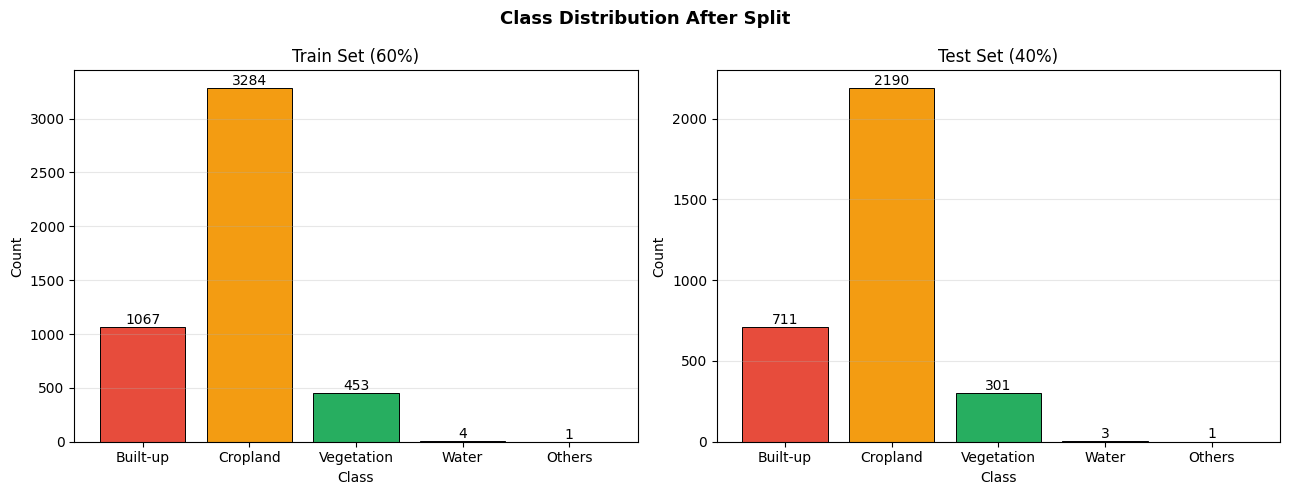

In [13]:
# visualizing class distribution in train and test
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#e74c3c', '#f39c12', '#27ae60', '#2980b9', '#95a5a6']

for ax, subset, title in zip(
    axes,
    [train_df, test_df],
    ['Train Set (60%)', 'Test Set (40%)']
):
    counts = subset['label'].value_counts().reindex(LABEL_CLASSES, fill_value=0)
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.7)

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(val), ha='center', va='bottom', fontsize=10)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Class Distribution After Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q2_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Q3 - Model Training and Evaluation

In [15]:
# custom dataset class for pytorch
# just reads the png file and returns (image tensor, label) pair

class SentinelDataset(Dataset):
    def __init__(self, dataframe, rgb_dir, transform=None):
        self.df = dataframe
        self.rgb_dir = rgb_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.rgb_dir, row['filename'])
        image = Image.open(img_path).convert('RGB')
        label = int(row['label_idx'])
        if self.transform:
            image = self.transform(image)
        return image, label

In [16]:
# normalizing with imagenet mean/std since resnet18 was pretrained on imagenet
# adding some augmentation for train set to prevent overfitting

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# no augmentation for test, just normalize
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = SentinelDataset(train_df, RGB_DIR, transform=train_transform)
test_dataset  = SentinelDataset(test_df,  RGB_DIR, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print('train batches:', len(train_loader))
print('test batches:', len(test_loader))

train batches: 151
test batches: 101


In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('using:', device)

NUM_CLASSES = len(LABEL_CLASSES)  # 5

# loading pretrained resnet18 from torchvision
# it was trained on imagenet (1000 classes)
# replacing the last fc layer with one that outputs 5 classes instead
model = models.resnet18(weights='DEFAULT')
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# reducing lr every 5 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

NUM_EPOCHS = 15
train_losses = []
train_accs = []

print('starting training...')

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

    scheduler.step()
    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    print(f'epoch {epoch+1}/{NUM_EPOCHS} | loss: {epoch_loss:.4f} | acc: {epoch_acc:.4f}')

print('done training')

using: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


starting training...
epoch 1/15 | loss: 0.4615 | acc: 0.8482
epoch 2/15 | loss: 0.2093 | acc: 0.9310
epoch 3/15 | loss: 0.1545 | acc: 0.9441
epoch 4/15 | loss: 0.1535 | acc: 0.9443
epoch 5/15 | loss: 0.1313 | acc: 0.9578
epoch 6/15 | loss: 0.0875 | acc: 0.9717
epoch 7/15 | loss: 0.0652 | acc: 0.9798
epoch 8/15 | loss: 0.0535 | acc: 0.9817
epoch 9/15 | loss: 0.0412 | acc: 0.9877
epoch 10/15 | loss: 0.0397 | acc: 0.9892
epoch 11/15 | loss: 0.0342 | acc: 0.9894
epoch 12/15 | loss: 0.0199 | acc: 0.9950
epoch 13/15 | loss: 0.0196 | acc: 0.9958
epoch 14/15 | loss: 0.0204 | acc: 0.9933
epoch 15/15 | loss: 0.0129 | acc: 0.9971
done training


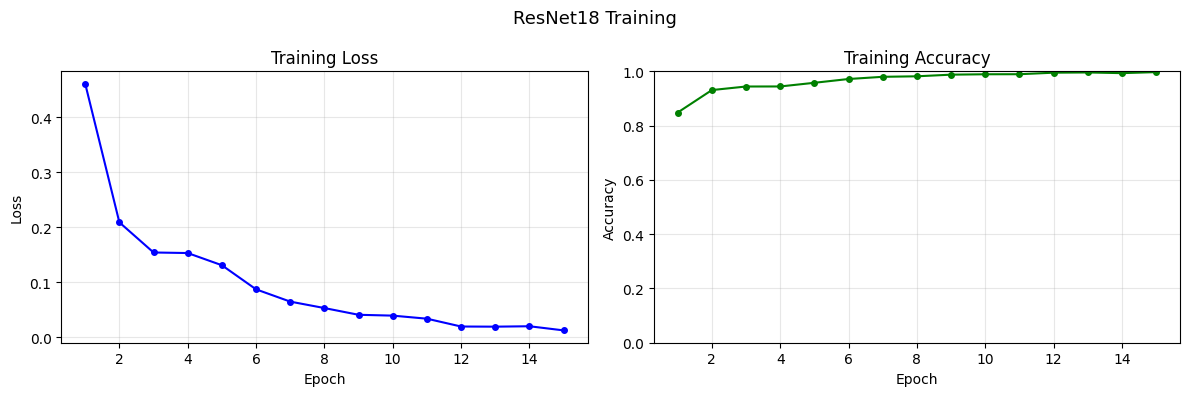

In [18]:
# plotting training curves to see if model was actually learning
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, NUM_EPOCHS+1), train_losses, 'b-o', markersize=4)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, NUM_EPOCHS+1), train_accs, 'g-o', markersize=4)
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

plt.suptitle('ResNet18 Training', fontsize=13)
plt.tight_layout()
plt.savefig('q3_training.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# evaluating on test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():  # no need to compute gradients during eval
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
f1_macro    = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
f1_per_class = f1_score(all_labels, all_preds, average=None,      zero_division=0)

print(f'test accuracy:     {acc:.4f}')
print(f'macro f1:          {f1_macro:.4f}')
print(f'weighted f1:       {f1_weighted:.4f}')
print('\nper class f1:')
for cls, f1 in zip(LABEL_CLASSES, f1_per_class):
    print(f'  {cls:<15} {f1:.4f}')

test accuracy:     0.9460
macro f1:          0.6766
weighted f1:       0.9450

per class f1:
  Built-up        0.9183
  Cropland        0.9707
  Vegetation      0.8275
  Water           0.6667
  Others          0.0000


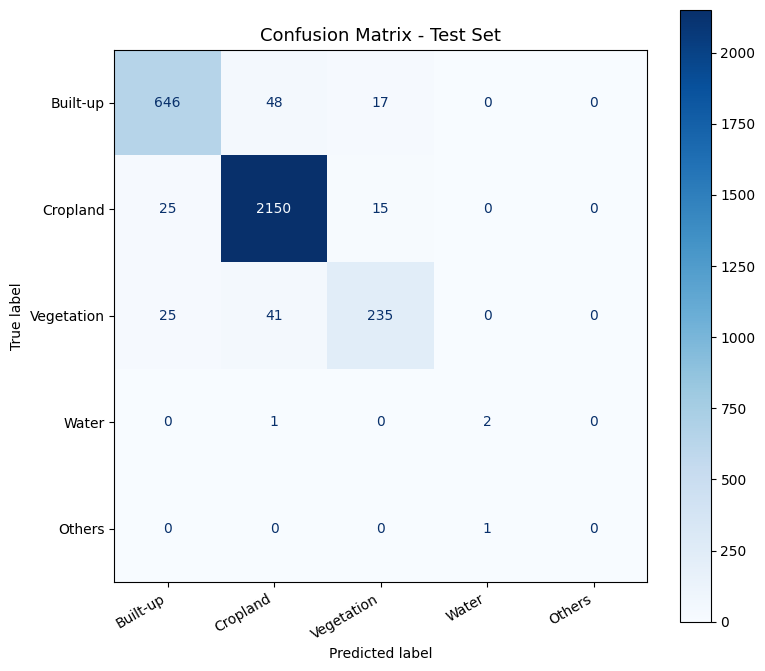

In [20]:
# confusion matrix
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_CLASSES)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Confusion Matrix - Test Set', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('q3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations from Confusion Matrix

- Cropland has the most samples so the model predicts it most confidently
- Vegetation and Cropland get confused sometimes - both look greenish in RGB so makes sense
- Water has very few samples so recall is low for that class (class imbalance problem)
- Built-up is mostly predicted correctly since urban areas have a distinct grey texture
- Others class has mixed results since it includes multiple different land types grouped together

In [21]:
# final summary
print('total images before filtering:', len(df))
print('total images after filtering:', len(filtered_gdf))
print('train samples:', len(train_df))
print('test samples:', len(test_df))
print(f'test accuracy: {acc:.4f}')
print(f'macro f1: {f1_macro:.4f}')
print(f'weighted f1: {f1_weighted:.4f}')

total images before filtering: 9216
total images after filtering: 8015
train samples: 4809
test samples: 3206
test accuracy: 0.9460
macro f1: 0.6766
weighted f1: 0.9450
